# TerraFlux Model Training (Step-by-Step)

This notebook trains all three TerraFlux models with:
- clear input inspection
- hyperparameter tuning
- feature reduction with controlled performance loss
- visual diagnostics

Models covered:
1. Module 1: ESA SOC regression
2. Module 2: Rural emission risk classification
3. Module 3: SRDB annual respiration regression

In [1]:
import sys
from pathlib import Path
import json

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    KFold,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_score,
)
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix,
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from xgboost import XGBRegressor, XGBClassifier

ROOT = Path('../../').resolve()
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.config import (
    PROCESSED_FILES,
    WEIGHTS_DIR,
    PREPROCESS_DIR,
    ESA_TARGET_COL,
    RANDOM_SEED,
    CV_FOLDS,
    HYPERPARAM_SEARCH_ITERS,
    MAX_REGRESSION_RMSE_LOSS,
    MAX_CLASSIFICATION_F1_DROP,
)

pd.set_option('display.max_columns', 120)
sns.set_theme(style='whitegrid')

print('Project root:', ROOT)
print('Weights dir :', WEIGHTS_DIR)
print('Prep dir    :', PREPROCESS_DIR)

Project root: C:\Users\justi\Downloads\ML project data\Terraflux
Weights dir : C:\Users\justi\Downloads\ML project data\Terraflux\models\weights
Prep dir    : C:\Users\justi\Downloads\ML project data\Terraflux\models\preprocessors


## Helper Functions

In [2]:
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def plot_reduction_curve(df_curve, metric_col, title, y_label):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    ax.plot(df_curve['n_features'], df_curve[metric_col], marker='o')
    ax.set_xlabel('Number of features')
    ax.set_ylabel(y_label)
    ax.set_title(title)
    plt.show()

def print_regression(y_true, y_pred, title='Regression Metrics'):
    print(title)
    print('RMSE:', round(rmse(y_true, y_pred), 4))
    print('MAE :', round(float(mean_absolute_error(y_true, y_pred)), 4))
    print('R2  :', round(float(r2_score(y_true, y_pred)), 4))

def is_binary_series(series):
    vals = set(series.dropna().unique().tolist())
    return vals.issubset({0, 1, False, True})

## Module 1: ESA SOC Regression

### 1) Input inspection

In [3]:
esa_df = pd.read_csv(PROCESSED_FILES['esa_train'])
print('Shape:', esa_df.shape)
display(esa_df.head(3))

X1 = esa_df.drop(columns=[ESA_TARGET_COL])
y1 = esa_df[ESA_TARGET_COL].copy()
print('X shape:', X1.shape, '| y shape:', y1.shape)

Shape: (23898, 61)


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,PC_11,PC_12,PC_13,PC_14,PC_15,PC_16,PC_17,PC_18,PC_19,PC_20,PC_21,PC_22,PC_23,PC_24,PC_25,PC_26,PC_27,PC_28,PC_29,PC_30,PC_31,PC_32,PC_33,PC_34,PC_35,PC_36,PC_37,PC_38,PC_39,PC_40,PC_41,PC_42,PC_43,PC_44,PC_45,PC_46,PC_47,PC_48,PC_49,PC_50,PC_51,PC_52,PC_53,PC_54,PC_55,PC_56,PC_57,PC_58,PC_59,PC_60,logoc_d.f
0,3.772226,-3.768648,0.837889,-5.156308,-0.813787,-3.234172,-1.120613,3.444649,-1.191004,-1.053877,-0.226868,2.748877,0.392589,-0.183335,0.301095,0.688012,-0.858468,-0.902981,0.476852,-0.349496,0.358943,-0.575217,-1.026842,-0.157275,0.659975,0.413426,0.208419,-0.787059,-0.551682,0.083122,0.030991,-0.121455,0.440975,-0.592054,-0.355766,-0.212017,-0.123712,-0.062549,0.099353,-0.294793,-0.443387,-0.126517,0.138815,-0.090070,0.913806,0.594134,-0.440555,-0.162943,-0.747492,-0.284343,1.249864,0.655750,0.049096,0.793758,-0.186165,0.425859,-0.153938,-0.647021,0.052653,-0.603093,5.220388
1,4.679112,-3.600828,-1.423638,-5.529601,-0.125095,-3.054660,-0.038824,3.845371,-2.020001,-0.388338,-0.964363,-0.124980,-1.659856,0.173654,0.953930,-0.919816,0.457923,0.552297,-0.848130,-0.325925,-3.428382,-0.671530,0.406696,0.849984,-0.516735,0.208783,-1.901930,1.881582,-1.071171,1.025126,-0.922346,0.492749,-0.598853,0.033371,-1.361385,-0.763344,0.046210,-0.000059,-0.054733,-1.140876,-0.752149,-0.568502,-0.139994,0.081664,1.274134,1.885618,0.389295,1.249999,0.217858,0.334120,1.437800,0.449869,-0.097359,0.473236,0.013520,-1.246294,-1.405060,0.696477,-0.250902,-0.842326,3.335679
2,3.898829,-3.827087,1.565726,-4.344070,-1.295705,-3.474332,-0.420283,3.799724,-1.499812,-1.592073,-0.887825,2.800766,-0.056092,-0.116659,-0.191159,0.143878,-0.832373,-0.295116,0.164494,-0.119939,0.137478,-0.803760,-0.881286,-0.057530,0.614820,0.763368,0.065593,-0.868278,-0.073150,0.061383,0.335655,-0.165761,0.502753,-0.623062,-0.283631,-0.776623,-0.338222,0.352807,0.030581,-0.262395,0.042069,0.103193,-0.115813,-0.142397,0.686436,0.761009,-0.305291,-0.925953,-0.769126,0.018789,0.504683,-1.202139,-0.020875,-0.216385,1.497578,-0.772020,0.206380,0.195774,-0.148379,-1.011593,3.887080


X shape: (23898, 60) | y shape: (23898,)


### 2) Hyperparameter tuning (cross-validated)

In [4]:
base_m1 = XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_SEED,
    n_jobs=2,
    tree_method='hist',
)

param_dist_m1 = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.0, 0.1, 0.3],
    'reg_alpha': [0.0, 0.01, 0.1],
    'reg_lambda': [1.0, 1.5, 2.0],
}

cv_m1 = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
search_m1 = RandomizedSearchCV(
    estimator=base_m1,
    param_distributions=param_dist_m1,
    n_iter=HYPERPARAM_SEARCH_ITERS,
    scoring='neg_root_mean_squared_error',
    cv=cv_m1,
    random_state=RANDOM_SEED,
    n_jobs=2,
    verbose=1,
)
search_m1.fit(X1, y1)
best_m1 = search_m1.best_estimator_
baseline_m1_rmse = float(-search_m1.best_score_)
print('Best CV RMSE:', round(baseline_m1_rmse, 4))
print('Best params :', search_m1.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


Best CV RMSE: 0.553
Best params : {'subsample': 0.8, 'reg_lambda': 1.0, 'reg_alpha': 0.0, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.08, 'gamma': 0.0, 'colsample_bytree': 0.6}


### 3) Feature reduction sweep (PCA components)

,n_features,cv_rmse
0,10,0.722126
1,15,0.573742
2,20,0.561243
3,30,0.553898
4,40,0.551349
5,50,0.554371
6,60,0.553011


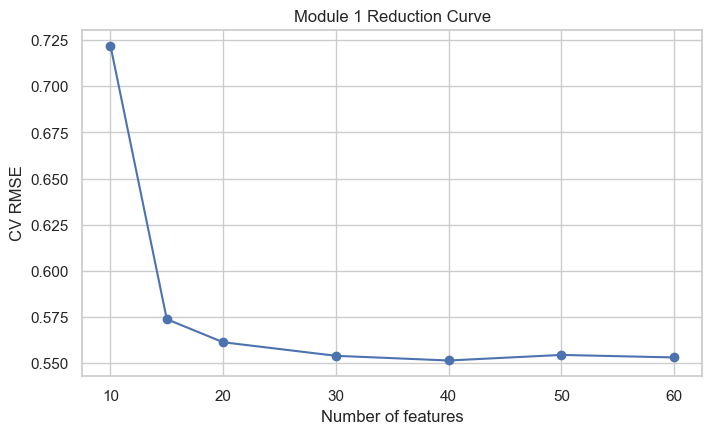

Selected features: 20 / 60 | RMSE limit: 0.5696


In [5]:
ordered_m1_features = sorted(
    X1.columns.tolist(),
    key=lambda n: int(n.split('_')[1]) if '_' in n and n.split('_')[1].isdigit() else 9999,
)
candidates_m1 = sorted(set([10, 15, 20, 30, 40, 50, min(60, X1.shape[1]), X1.shape[1]]))

m1_curve = []
for k in candidates_m1:
    cols = ordered_m1_features[:k]
    mdl = clone(best_m1)
    scores = cross_val_score(mdl, X1[cols], y1, cv=cv_m1, scoring='neg_root_mean_squared_error', n_jobs=2)
    m1_curve.append({'n_features': k, 'cv_rmse': float(-scores.mean())})

m1_curve_df = pd.DataFrame(m1_curve)
display(m1_curve_df)
plot_reduction_curve(m1_curve_df, 'cv_rmse', 'Module 1 Reduction Curve', 'CV RMSE')

limit_m1 = baseline_m1_rmse * (1 + MAX_REGRESSION_RMSE_LOSS)
selected_k_m1 = int(m1_curve_df[m1_curve_df['cv_rmse'] <= limit_m1]['n_features'].iloc[0]) if (m1_curve_df['cv_rmse'] <= limit_m1).any() else X1.shape[1]
selected_m1_features = ordered_m1_features[:selected_k_m1]
print('Selected features:', selected_k_m1, '/', X1.shape[1], '| RMSE limit:', round(limit_m1, 4))

### 4) Final fit + visual diagnostics

Module 1 Holdout Metrics
RMSE: 0.5753
MAE : 0.4227
R2  : 0.687


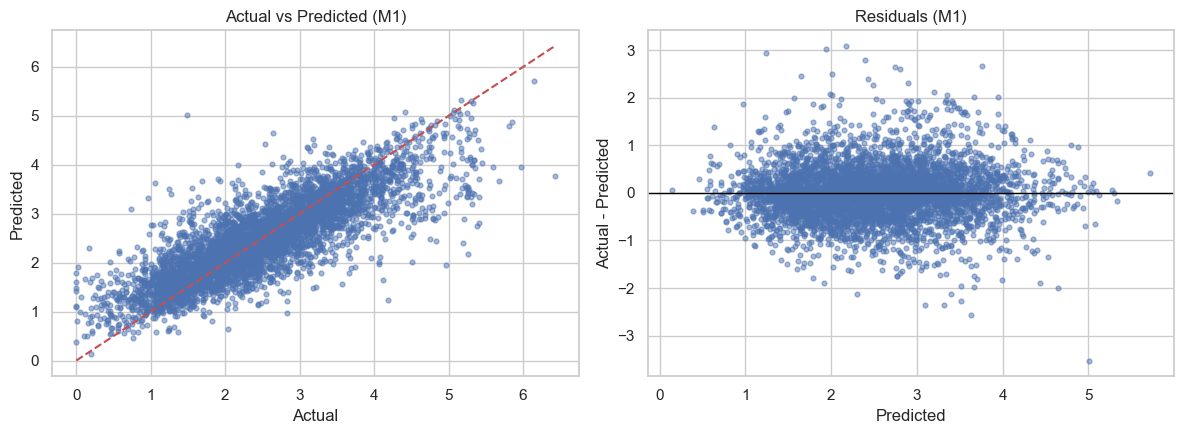

In [6]:
X1_sel = X1[selected_m1_features]
X1_train, X1_val, y1_train, y1_val = train_test_split(X1_sel, y1, test_size=0.2, random_state=RANDOM_SEED)

final_m1 = clone(best_m1)
final_m1.fit(X1_train, y1_train, eval_set=[(X1_train, y1_train), (X1_val, y1_val)], verbose=False)

pred1 = final_m1.predict(X1_val)
print_regression(y1_val, pred1, title='Module 1 Holdout Metrics')

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].scatter(y1_val, pred1, s=12, alpha=0.5)
lo = min(y1_val.min(), pred1.min())
hi = max(y1_val.max(), pred1.max())
axs[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
axs[0].set_title('Actual vs Predicted (M1)')
axs[0].set_xlabel('Actual')
axs[0].set_ylabel('Predicted')

res1 = y1_val - pred1
axs[1].scatter(pred1, res1, s=12, alpha=0.5)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('Residuals (M1)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual - Predicted')

plt.tight_layout()
plt.show()

## Module 2: Rural Emission Risk Classification

### 1) Input inspection and preprocessing

In [7]:
rural_df = pd.read_csv(PROCESSED_FILES['rural_carbon'])
print('Shape:', rural_df.shape)
display(rural_df.head(3))

drop_cols_m2 = ['Emission_Risk']
if 'Carbon_Emission_tCO2' in rural_df.columns:
    drop_cols_m2.append('Carbon_Emission_tCO2')

X2 = rural_df.drop(columns=drop_cols_m2).copy()
for c in X2.columns:
    if X2[c].dtype == bool:
        X2[c] = X2[c].astype(int)

enc2 = LabelEncoder()
y2 = enc2.fit_transform(rural_df['Emission_Risk'])
print('Classes:', list(enc2.classes_))

num_cols2 = [c for c in X2.columns if pd.api.types.is_numeric_dtype(X2[c])]
scale_cols2 = [c for c in num_cols2 if not is_binary_series(X2[c])]
scaler2 = StandardScaler()
if scale_cols2:
    X2.loc[:, scale_cols2] = scaler2.fit_transform(X2[scale_cols2])
print('X shape:', X2.shape)

Shape: (3000, 316)


,Month,Fertilizer_Usage_kg,Crop_Area_ha,Livestock_Cows,Livestock_Pigs,Household_Energy_kWh,Renewable_Energy_Fraction,Temperature_C,Rainfall_mm,Carbon_Emission_tCO2,Year,Emission_Risk,Livestock_Total,Renewable_Energy_kWh,Region_R0002,Region_R0003,Region_R0004,Region_R0005,Region_R0006,Region_R0007,Region_R0008,Region_R0009,Region_R0010,Region_R0011,Region_R0012,Region_R0013,Region_R0014,Region_R0015,Region_R0016,Region_R0017,Region_R0018,Region_R0019,Region_R0020,Region_R0021,Region_R0022,Region_R0023,Region_R0024,Region_R0025,Region_R0026,Region_R0027,Region_R0028,Region_R0029,Region_R0030,Region_R0031,Region_R0032,Region_R0033,Region_R0034,Region_R0035,Region_R0036,Region_R0037,Region_R0038,Region_R0039,Region_R0040,Region_R0041,Region_R0042,Region_R0043,Region_R0044,Region_R0045,Region_R0046,Region_R0047,...,Region_R0244,Region_R0245,Region_R0246,Region_R0247,Region_R0248,Region_R0249,Region_R0250,Region_R0251,Region_R0252,Region_R0253,Region_R0254,Region_R0255,Region_R0256,Region_R0257,Region_R0258,Region_R0259,Region_R0260,Region_R0261,Region_R0262,Region_R0263,Region_R0264,Region_R0265,Region_R0266,Region_R0267,Region_R0268,Region_R0269,Region_R0270,Region_R0271,Region_R0272,Region_R0273,Region_R0274,Region_R0275,Region_R0276,Region_R0277,Region_R0278,Region_R0279,Region_R0280,Region_R0281,Region_R0282,Region_R0283,Region_R0284,Region_R0285,Region_R0286,Region_R0287,Region_R0288,Region_R0289,Region_R0290,Region_R0291,Region_R0292,Region_R0293,Region_R0294,Region_R0295,Region_R0296,Region_R0297,Region_R0298,Region_R0299,Region_R0300,Crop_Type_Maize,Crop_Type_Rice,Crop_Type_Wheat
0,-0.757329,-0.407911,0.739476,-1.703205,0.516532,-0.085013,0.257045,0.381142,-1.095227,5.91,1.509256,Low,-0.301842,0.164679,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False
1,1.276939,-0.537377,1.517671,1.594777,1.660017,0.898596,-0.017246,0.532377,1.458223,21.63,0.011648,High,2.222876,0.458336,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,0.114500,-1.496811,0.076854,1.178190,0.343277,1.516639,1.594214,0.171740,-1.531608,9.24,0.510851,Medium,0.842906,2.821606,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False


Classes: ['High', 'Low', 'Medium']
X shape: (3000, 314)


### 2) Hyperparameter tuning (cross-validated)

In [8]:
base_m2 = XGBClassifier(
    objective='multi:softprob',
    num_class=len(np.unique(y2)),
    eval_metric='mlogloss',
    random_state=RANDOM_SEED,
    n_jobs=2,
    tree_method='hist',
)

param_dist_m2 = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.0, 0.1, 0.3],
    'reg_alpha': [0.0, 0.01, 0.1],
    'reg_lambda': [1.0, 1.5, 2.0],
}

cv_m2 = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
search_m2 = RandomizedSearchCV(
    estimator=base_m2,
    param_distributions=param_dist_m2,
    n_iter=HYPERPARAM_SEARCH_ITERS,
    scoring='f1_weighted',
    cv=cv_m2,
    random_state=RANDOM_SEED,
    n_jobs=2,
    verbose=1,
)
search_m2.fit(X2, y2)
best_m2 = search_m2.best_estimator_
baseline_m2_f1 = float(search_m2.best_score_)
print('Best CV weighted-F1:', round(baseline_m2_f1, 4))
print('Best params:', search_m2.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits


KeyboardInterrupt: 

### 3) Feature reduction sweep

,n_features,cv_weighted_f1
0,8,0.551856
1,12,0.553169
2,16,0.564712
3,24,0.558990
4,32,0.556616
5,48,0.559606
6,64,0.562272
7,96,0.561185
8,128,0.563108
9,314,0.561877


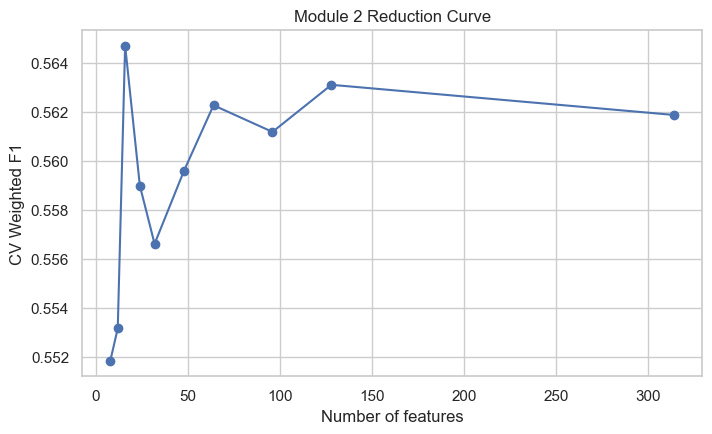

Selected features: 8 / 314 | Min acceptable F1: 0.5514


In [ ]:
imp2 = np.asarray(best_m2.feature_importances_)
order2 = np.argsort(imp2)[::-1]
ordered_m2_features = X2.columns[order2].tolist()

candidates_m2 = sorted(set([8, 12, 16, 24, 32, 48, 64, min(96, X2.shape[1]), min(128, X2.shape[1]), X2.shape[1]]))
m2_curve = []
for k in candidates_m2:
    cols = ordered_m2_features[:k]
    mdl = clone(best_m2)
    scores = cross_val_score(mdl, X2[cols], y2, cv=cv_m2, scoring='f1_weighted', n_jobs=2)
    m2_curve.append({'n_features': k, 'cv_weighted_f1': float(scores.mean())})

m2_curve_df = pd.DataFrame(m2_curve)
display(m2_curve_df)
plot_reduction_curve(m2_curve_df, 'cv_weighted_f1', 'Module 2 Reduction Curve', 'CV Weighted F1')

min_ok_f1 = baseline_m2_f1 - MAX_CLASSIFICATION_F1_DROP
selected_k_m2 = int(m2_curve_df[m2_curve_df['cv_weighted_f1'] >= min_ok_f1]['n_features'].iloc[0]) if (m2_curve_df['cv_weighted_f1'] >= min_ok_f1).any() else X2.shape[1]
selected_m2_features = ordered_m2_features[:selected_k_m2]
print('Selected features:', selected_k_m2, '/', X2.shape[1], '| Min acceptable F1:', round(min_ok_f1, 4))

### 4) Final fit + confusion matrix

Module 2 Holdout Accuracy: 0.5717
              precision    recall  f1-score   support

        High       0.63      0.64      0.63       200
         Low       0.66      0.68      0.67       200
      Medium       0.41      0.40      0.40       200

    accuracy                           0.57       600
   macro avg       0.57      0.57      0.57       600
weighted avg       0.57      0.57      0.57       600



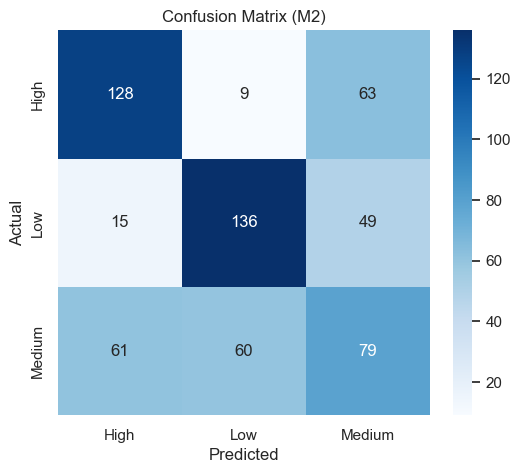

In [ ]:
X2_sel = X2[selected_m2_features]
X2_train, X2_val, y2_train, y2_val = train_test_split(X2_sel, y2, test_size=0.2, random_state=RANDOM_SEED, stratify=y2)

final_m2 = clone(best_m2)
final_m2.fit(X2_train, y2_train)
pred2 = final_m2.predict(X2_val)

acc2 = accuracy_score(y2_val, pred2)
print('Module 2 Holdout Accuracy:', round(float(acc2), 4))
print(classification_report(y2_val, pred2, target_names=enc2.classes_))

cm2 = confusion_matrix(y2_val, pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Blues', xticklabels=enc2.classes_, yticklabels=enc2.classes_)
plt.title('Confusion Matrix (M2)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Module 3: SRDB Annual Respiration Regression

### 1) Input inspection and preprocessing

In [ ]:
srdb_df = pd.read_csv(PROCESSED_FILES['srdb_temporal'])
srdb_df = srdb_df.dropna(subset=['Rs_annual']).copy()
print('Shape:', srdb_df.shape)
display(srdb_df.head(3))

leakage_cols = [
    'Record_number', 'Rs_annual', 'Rs_spring', 'Rs_summer', 'Rs_autumn',
    'Rs_winter', 'Rs_growingseason', 'spring_ratio', 'summer_ratio',
    'autumn_ratio', 'winter_ratio', 'Decade'
]

X3_raw = srdb_df.drop(columns=[c for c in leakage_cols if c in srdb_df.columns])
y3 = np.log1p(srdb_df['Rs_annual'])

X3 = pd.get_dummies(X3_raw, columns=['Biome', 'Ecosystem_type'], drop_first=True)
X3 = X3.fillna(X3.median(numeric_only=True))
print('X shape:', X3.shape, '| y shape:', y3.shape)

Shape: (5551, 19)


,Record_number,Study_midyear,Latitude,Longitude,Biome,Ecosystem_type,MAT,MAP,Rs_annual,Rs_spring,Rs_summer,Rs_autumn,Rs_winter,Rs_growingseason,Decade,spring_ratio,summer_ratio,autumn_ratio,winter_ratio
0,1.0,2001.5,56.63,-99.94,Boreal,Forest,0.8,450.0,255.0,NaN,NaN,NaN,NaN,1.30,2000,NaN,NaN,NaN,NaN
1,2.0,2001.5,56.46,-99.97,Boreal,Forest,0.8,450.0,85.0,NaN,NaN,NaN,NaN,0.60,2000,NaN,NaN,NaN,NaN
2,3.0,2001.5,55.91,-98.98,Boreal,Forest,0.8,450.0,425.0,NaN,NaN,NaN,NaN,1.98,2000,NaN,NaN,NaN,NaN


X shape: (5551, 27) | y shape: (5551,)


### 2) Hyperparameter tuning (cross-validated)

In [ ]:
base_m3 = XGBRegressor(
    objective='reg:squarederror',
    random_state=RANDOM_SEED,
    n_jobs=2,
    tree_method='hist',
)

param_dist_m3 = {
    'n_estimators': [200, 300, 500, 700],
    'max_depth': [3, 4, 5, 6, 8],
    'learning_rate': [0.03, 0.05, 0.08, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5],
    'gamma': [0.0, 0.1, 0.3],
    'reg_alpha': [0.0, 0.01, 0.1],
    'reg_lambda': [1.0, 1.5, 2.0],
}

cv_m3 = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM_SEED)
search_m3 = RandomizedSearchCV(
    estimator=base_m3,
    param_distributions=param_dist_m3,
    n_iter=HYPERPARAM_SEARCH_ITERS,
    scoring='neg_root_mean_squared_error',
    cv=cv_m3,
    random_state=RANDOM_SEED,
    n_jobs=2,
    verbose=1,
)
search_m3.fit(X3, y3)
best_m3 = search_m3.best_estimator_
baseline_m3_rmse = float(-search_m3.best_score_)
print('Best CV RMSE (log):', round(baseline_m3_rmse, 4))
print('Best params:', search_m3.best_params_)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
Best CV RMSE (log): 0.3702
Best params: {'subsample': 1.0, 'reg_lambda': 2.0, 'reg_alpha': 0.1, 'n_estimators': 300, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.1, 'gamma': 0.0, 'colsample_bytree': 1.0}


### 3) Feature reduction sweep

,n_features,cv_rmse_log
0,5,0.496368
1,8,0.395386
2,12,0.391356
3,16,0.373855
4,24,0.368829
5,27,0.368671


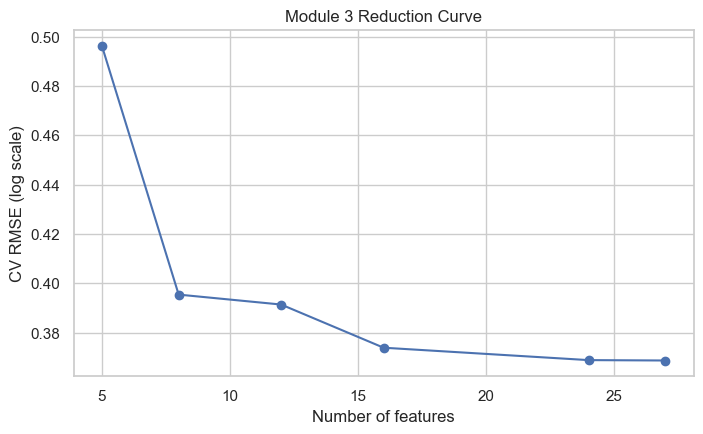

Selected features: 16 / 27 | RMSE limit: 0.3813


In [ ]:
imp3 = np.asarray(getattr(best_m3, 'feature_importances_', np.zeros(X3.shape[1])))
order3 = np.argsort(imp3)[::-1]
ordered_m3_features = X3.columns[order3].tolist()

candidates_m3 = sorted(set([5, 8, 12, 16, 24, min(32, X3.shape[1]), X3.shape[1]]))
m3_curve = []
for k in candidates_m3:
    cols = ordered_m3_features[:k]
    mdl = clone(best_m3)
    scores = cross_val_score(mdl, X3[cols], y3, cv=cv_m3, scoring='neg_root_mean_squared_error', n_jobs=2)
    m3_curve.append({'n_features': k, 'cv_rmse_log': float(-scores.mean())})

m3_curve_df = pd.DataFrame(m3_curve)
display(m3_curve_df)
plot_reduction_curve(m3_curve_df, 'cv_rmse_log', 'Module 3 Reduction Curve', 'CV RMSE (log scale)')

limit_m3 = baseline_m3_rmse * (1 + MAX_REGRESSION_RMSE_LOSS)
selected_k_m3 = int(m3_curve_df[m3_curve_df['cv_rmse_log'] <= limit_m3]['n_features'].iloc[0]) if (m3_curve_df['cv_rmse_log'] <= limit_m3).any() else X3.shape[1]
selected_m3_features = ordered_m3_features[:selected_k_m3]
print('Selected features:', selected_k_m3, '/', X3.shape[1], '| RMSE limit:', round(limit_m3, 4))

### 4) Final fit + visual diagnostics

Module 3 Holdout Metrics (log scale)
RMSE: 0.3773
MAE : 0.2477
R2  : 0.7324
Module 3 Holdout Metrics (real scale)
RMSE: 428.9463
MAE : 202.0619
R2  : 0.681


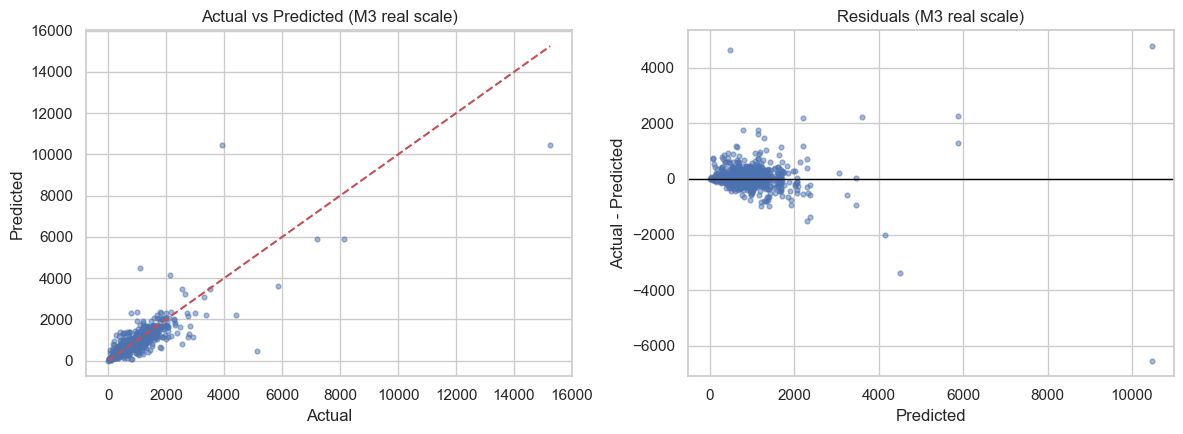

In [ ]:
X3_sel = X3[selected_m3_features]
X3_train, X3_val, y3_train, y3_val = train_test_split(X3_sel, y3, test_size=0.2, random_state=RANDOM_SEED)

final_m3 = clone(best_m3)
final_m3.fit(X3_train, y3_train, eval_set=[(X3_train, y3_train), (X3_val, y3_val)], verbose=False)

pred3_log = final_m3.predict(X3_val)
print_regression(y3_val, pred3_log, title='Module 3 Holdout Metrics (log scale)')

y3_val_real = np.expm1(y3_val)
pred3_real = np.expm1(pred3_log)
print_regression(y3_val_real, pred3_real, title='Module 3 Holdout Metrics (real scale)')

fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
axs[0].scatter(y3_val_real, pred3_real, s=12, alpha=0.5)
lo = min(y3_val_real.min(), pred3_real.min())
hi = max(y3_val_real.max(), pred3_real.max())
axs[0].plot([lo, hi], [lo, hi], 'r--', linewidth=1.5)
axs[0].set_title('Actual vs Predicted (M3 real scale)')
axs[0].set_xlabel('Actual')
axs[0].set_ylabel('Predicted')

res3 = y3_val_real - pred3_real
axs[1].scatter(pred3_real, res3, s=12, alpha=0.5)
axs[1].axhline(0, color='black', linewidth=1)
axs[1].set_title('Residuals (M3 real scale)')
axs[1].set_xlabel('Predicted')
axs[1].set_ylabel('Actual - Predicted')

plt.tight_layout()
plt.show()

## Save Artifacts

This cell writes optimized models and metadata artifacts used by the inference pipeline.

In [ ]:
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)
PREPROCESS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(final_m1, WEIGHTS_DIR / 'esa_soc_model.pkl')
joblib.dump(final_m2, WEIGHTS_DIR / 'm2_rural_risk_model.pkl')
joblib.dump(final_m3, WEIGHTS_DIR / 'm3_srdb_regression_model.pkl')

joblib.dump(enc2, PREPROCESS_DIR / 'm2_risk_encoder.pkl')
joblib.dump(scaler2, PREPROCESS_DIR / 'rural_scaler.pkl')
joblib.dump(selected_m2_features, PREPROCESS_DIR / 'm2_selected_features.pkl')
joblib.dump(selected_m3_features, PREPROCESS_DIR / 'm3_srdb_features.pkl')

m1_report = {
    'baseline_cv_rmse': baseline_m1_rmse,
    'max_allowed_rmse_loss_ratio': MAX_REGRESSION_RMSE_LOSS,
    'selected_feature_count': len(selected_m1_features),
    'total_feature_count': X1.shape[1],
    'selected_features': selected_m1_features,
    'reduction_curve': m1_curve,
}

m2_report = {
    'baseline_cv_weighted_f1': baseline_m2_f1,
    'max_allowed_f1_drop': MAX_CLASSIFICATION_F1_DROP,
    'selected_feature_count': len(selected_m2_features),
    'total_feature_count': X2.shape[1],
    'selected_features': selected_m2_features,
    'reduction_curve': m2_curve,
}

m3_report = {
    'baseline_cv_rmse_log': baseline_m3_rmse,
    'max_allowed_rmse_loss_ratio': MAX_REGRESSION_RMSE_LOSS,
    'selected_feature_count': len(selected_m3_features),
    'total_feature_count': X3.shape[1],
    'selected_features': selected_m3_features,
    'reduction_curve': m3_curve,
}

(WEIGHTS_DIR / 'm1_training_report.json').write_text(json.dumps(m1_report, indent=2), encoding='utf-8')
(WEIGHTS_DIR / 'm2_training_report.json').write_text(json.dumps(m2_report, indent=2), encoding='utf-8')
(WEIGHTS_DIR / 'm3_training_report.json').write_text(json.dumps(m3_report, indent=2), encoding='utf-8')

print('Saved all model artifacts and reports.')

Saved all model artifacts and reports.
